# Airbnb NYC Bookings Analysis

**Exploratory data analysis of 48,895 New York City Airbnb listings (2019)** — where supply sits, how prices behave, and which listing decisions coincide with stronger guest engagement.

| | |
|---|---|
| **Author** | Aryan Roy |
| **Dataset** | [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (Kaggle, 2019 snapshot) |
| **Stack** | Python · pandas · NumPy · Matplotlib · Seaborn · SciPy |
| **Type** | Exploratory data analysis with statistical testing |

### Contents
1. Business context and questions
2. Setup
3. Data loading and audit
4. Data cleaning and feature engineering
5. Exploratory analysis — univariate, bivariate, multivariate
6. Statistical testing
7. Findings, recommendations and limitations

## 1. Business context and questions

Airbnb is a two-sided marketplace. Guests want the right place at the right price; hosts want to know how to position a listing so it gets booked. This notebook looks at the 2019 New York City listing snapshot from the point of view of a marketplace strategy team that also wants to give practical guidance back to hosts.

The analysis is organised around four questions:

1. **Supply** — where are listings concentrated (borough, neighbourhood, room type)?
2. **Pricing** — how do prices vary, and what does a "typical" nightly price look like?
3. **Engagement** — which price points and stay policies coincide with more guest reviews (used here as a proxy for booking activity)?
4. **Hosts** — how much of the market is run by single-property hosts versus professional multi-listing operators?

> **A note on "demand".** The dataset has no booking records. Review counts and reviews per month are the closest available signal of guest activity, so every statement about "engagement" below refers to reviews, not confirmed bookings.

## 2. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ---- Configuration ---------------------------------------------------------
DATA_PATH = Path("data/AB_NYC_2019.csv")   # download from Kaggle, see data/README.md
FIG_DIR = Path("images")                   # charts are exported here for the README
SAVE_FIGURES = True
RANDOM_STATE = 42

BOROUGHS = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
ROOM_TYPES = ["Entire home/apt", "Private room", "Shared room"]
BOROUGH_COLORS = dict(zip(BOROUGHS, sns.color_palette("deep", len(BOROUGHS))))
ROOM_COLORS = dict(zip(ROOM_TYPES, sns.color_palette("Set2", len(ROOM_TYPES))))

# ---- Plot styling ----------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid.axis": "y",
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


def save_fig(name: str) -> None:
    """Export the current figure to FIG_DIR (if enabled) and display it."""
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


def dollars(x, _=None) -> str:
    """Tick formatter: 1250 -> '$1,250'."""
    return f"${x:,.0f}"


def fmt_p(p: float) -> str:
    """Readable p-value (avoids printing 0.0 when the value underflows)."""
    return "< 1e-300" if p < 1e-300 else f"{p:.2e}"

## 3. Data loading and audit

In [2]:
def load_raw(path: Path) -> pd.DataFrame:
    """Read the raw listings CSV with a clear error if the file is missing."""
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at '{path.resolve()}'.\n"
            "Download AB_NYC_2019.csv from "
            "https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data "
            "and place it in the 'data/' folder."
        )
    return pd.read_csv(path)


raw = load_raw(DATA_PATH)
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Loaded 48,895 rows x 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**Data dictionary**

| Column | Description |
|---|---|
| `id` | Unique listing identifier |
| `name` | Listing title |
| `host_id`, `host_name` | Host identifier and display name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Neighbourhood within the borough |
| `latitude`, `longitude` | Listing coordinates |
| `room_type` | Entire home/apt, Private room or Shared room |
| `price` | Listed nightly price in USD |
| `minimum_nights` | Minimum length of stay the host requires |
| `number_of_reviews` | Total reviews received by the listing |
| `last_review` | Date of the most recent review |
| `reviews_per_month` | Average monthly review rate |
| `calculated_host_listings_count` | Number of listings the host has in this dataset |
| `availability_365` | Days the listing is open for booking over the next 365 days |

In [3]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(2),
    "unique_values": raw.nunique(),
})
audit

,dtype,missing,missing_%,unique_values
id,int64,0,0.00,48895
name,str,16,0.03,47905
host_id,int64,0,0.00,37457
host_name,str,21,0.04,11452
neighbourhood_group,str,0,0.00,5
neighbourhood,str,0,0.00,221
latitude,float64,0,0.00,19048
longitude,float64,0,0.00,14718
room_type,str,0,0.00,3
price,int64,0,0.00,674


In [4]:
print("Exact duplicate rows:      ", raw.duplicated().sum())
print("Duplicate listing IDs:     ", raw["id"].duplicated().sum())
print("Rows priced at $0:         ", (raw["price"] == 0).sum())
print("Minimum stay above 1 year: ", (raw["minimum_nights"] > 365).sum())
print("Missing reviews_per_month: ", raw["reviews_per_month"].isna().sum())
print("Zero-review listings:      ", (raw["number_of_reviews"] == 0).sum())
raw[["price", "minimum_nights", "number_of_reviews", "availability_365"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.99]
).round(2)

Exact duplicate rows:       0
Duplicate listing IDs:      0
Rows priced at $0:          11
Minimum stay above 1 year:  14
Missing reviews_per_month:  10052
Zero-review listings:       10052


,price,minimum_nights,number_of_reviews,availability_365
count,48895.00,48895.00,48895.00,48895.00
mean,152.72,7.03,23.27,112.78
std,240.15,20.51,44.55,131.62
min,0.00,1.00,0.00,0.00
25%,69.00,1.00,1.00,0.00
50%,106.00,3.00,5.00,45.00
75%,175.00,5.00,24.00,227.00
99%,799.00,45.00,214.00,365.00
max,10000.00,1250.00,629.00,365.00


**What the audit shows**

- Listing IDs are unique and there are no exact duplicate rows, so every row is a distinct listing.
- `last_review` and `reviews_per_month` are missing for the same ~20% of rows. That pattern matches the zero-review count exactly, which means the values are missing because the listing has *never been reviewed*, not because of a data-collection fault. The right fix is to treat the missing review rate as 0, not to invent a review date.
- A small number of listings have a `$0` price, and a few have minimum stays of over a year (up to 1,250 nights). Both are data-entry problems.
- `price` is very right-skewed (median far below the mean, maximum $10,000), so medians will be used for summaries and outliers are handled explicitly rather than dropped blindly.

## 4. Data cleaning and feature engineering

Every cleaning decision is applied inside one function that also records how many rows each step touched, so the pipeline is reproducible and auditable.

| Issue | Decision | Reasoning |
|---|---|---|
| `last_review` stored as mixed text formats | Parse as **month-first** dates | The export contains values like `10/19/2018` and `07-05-2019`; forcing day-first parsing silently swaps day and month and can create dates that lie beyond the data collection window |
| Missing `reviews_per_month` | Fill with **0** | Missing only when `number_of_reviews == 0` (verified in code) |
| Missing `last_review` | Leave as **NaT** | Filling with a made-up date would fabricate review activity |
| Missing `name` / `host_name` | Fill with `"Unknown"` | Keeps the rows; text fields are not used in calculations |
| `price` of $0 | **Drop** these rows | A $0 nightly price is not a real listing price; replacing it with an arbitrary floor would invent data |
| `minimum_nights` above 365 | **Clip** to 365 | A minimum stay longer than a year is an entry error; the row is otherwise valid |
| Very high prices | **Keep**, use medians and capped views | Luxury listings are real; they distort means, not medians |
| Rows sharing name + host + neighbourhood + room type | **Keep**, sensitivity-checked below | Each has a unique `id` and coordinates; hotels legitimately list several identical rooms |

In [5]:
MIN_VALID_PRICE = 1      # $0 listings are data-entry errors
MAX_MIN_NIGHTS = 365     # a minimum stay beyond one year is not a real policy
REPEAT_KEY = ["name", "host_name", "neighbourhood_group", "neighbourhood", "room_type"]


def clean_listings(raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Clean the raw listings table.

    Returns the cleaned DataFrame and a log with the number of rows affected by each step.
    """
    df = raw.copy()
    log = []

    def record(step: str, rows: int, action: str) -> None:
        log.append({"step": step, "rows_affected": int(rows), "action": action})

    # 1. Dates: the export mixes 'M/D/YYYY', 'MM-DD-YYYY' and ISO strings, all month-first.
    parsed = pd.to_datetime(df["last_review"], format="mixed", dayfirst=False, errors="coerce")
    unparsed = int((parsed.isna() & df["last_review"].notna()).sum())
    df["last_review"] = parsed
    record("Parse last_review", parsed.notna().sum(),
           f"Converted to datetime (month-first); {unparsed} unparseable values set to NaT")

    # 2. Missing text fields.
    missing_text = df[["name", "host_name"]].isna().any(axis=1).sum()
    df[["name", "host_name"]] = df[["name", "host_name"]].fillna("Unknown")
    record("Fill missing name/host_name", missing_text, "Set to 'Unknown'")

    # 3. reviews_per_month is only missing when the listing has no reviews.
    mismatch = (df["reviews_per_month"].isna() != df["number_of_reviews"].eq(0)).sum()
    filled = df["reviews_per_month"].isna().sum()
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0.0)
    record("Fill reviews_per_month", filled,
           f"Set to 0 for never-reviewed listings (rows where the pattern did not hold: {mismatch})")

    # 4. Invalid prices.
    bad_price = df["price"] < MIN_VALID_PRICE
    record("Drop invalid prices", bad_price.sum(), f"Removed rows with price < ${MIN_VALID_PRICE}")
    df = df.loc[~bad_price].copy()

    # 5. Impossible minimum stays.
    too_long = df["minimum_nights"] > MAX_MIN_NIGHTS
    df["minimum_nights"] = df["minimum_nights"].clip(upper=MAX_MIN_NIGHTS)
    record("Clip minimum_nights", too_long.sum(), f"Capped at {MAX_MIN_NIGHTS} nights")

    # 6. Clearer name for the host-level listing count.
    df = df.rename(columns={"calculated_host_listings_count": "host_listings_count"})
    record("Rename column", len(df), "calculated_host_listings_count -> host_listings_count")

    # 7. Possible repeat listings are reported, not removed (see sensitivity check).
    repeats = df.duplicated(subset=REPEAT_KEY, keep="first").sum()
    record("Flag possible repeat listings", repeats,
           "Retained; every row has a unique id and coordinates")

    return df.reset_index(drop=True), pd.DataFrame(log)


df, cleaning_log = clean_listings(raw)
print(f"Rows: {len(raw):,} raw -> {len(df):,} after cleaning")
cleaning_log

Rows: 48,895 raw -> 48,884 after cleaning


,step,rows_affected,action
0,Parse last_review,38843,Converted to datetime (month-first); 0 unparse...
1,Fill missing name/host_name,37,Set to 'Unknown'
2,Fill reviews_per_month,10052,Set to 0 for never-reviewed listings (rows whe...
3,Drop invalid prices,11,Removed rows with price < $1
4,Clip minimum_nights,14,Capped at 365 nights
5,Rename column,48884,calculated_host_listings_count -> host_listing...
6,Flag possible repeat listings,233,Retained; every row has a unique id and coordi...


In [6]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add analysis-ready features (ordered categories keep charts in a logical order)."""
    out = df.copy()

    out["price_band"] = pd.cut(
        out["price"],
        bins=[0, 50, 100, 150, 200, 300, 500, np.inf],
        labels=["<$50", "$50–99", "$100–149", "$150–199", "$200–299", "$300–499", "$500+"],
        right=False,
    )
    out["min_stay_band"] = pd.cut(
        out["minimum_nights"],
        bins=[0, 1, 3, 7, 29, MAX_MIN_NIGHTS],
        labels=["1 night", "2–3 nights", "4–7 nights", "8–29 nights", "30+ nights"],
    )
    out["host_segment"] = pd.cut(
        out["host_listings_count"],
        bins=[0, 1, 5, np.inf],
        labels=["Single listing", "2–5 listings", "6+ listings"],
    )
    out["has_reviews"] = out["number_of_reviews"] > 0
    out["no_availability"] = out["availability_365"] == 0
    return out


df = add_features(df)
df[["price", "price_band", "minimum_nights", "min_stay_band",
    "host_listings_count", "host_segment"]].sample(5, random_state=RANDOM_STATE)

,price,price_band,minimum_nights,min_stay_band,host_listings_count,host_segment
41309,99,$50–99,12,8–29 nights,4,2–5 listings
22079,90,$50–99,2,2–3 nights,4,2–5 listings
18778,80,$50–99,30,30+ nights,8,6+ listings
25492,60,$50–99,1,1 night,1,Single listing
44308,90,$50–99,4,4–7 nights,2,2–5 listings


**Validation** — the notebook stops here if the cleaned data breaks any of these expectations.

In [7]:
core_cols = ["id", "host_id", "neighbourhood_group", "neighbourhood", "room_type",
             "price", "minimum_nights", "number_of_reviews", "reviews_per_month",
             "host_listings_count", "availability_365"]

checks = {
    "Listing IDs are unique": df["id"].is_unique,
    "No missing values in core columns": bool(df[core_cols].notna().all().all()),
    "All prices are positive": bool((df["price"] > 0).all()),
    "Minimum nights between 1 and 365": bool(df["minimum_nights"].between(1, MAX_MIN_NIGHTS).all()),
    "Five expected boroughs": set(df["neighbourhood_group"]) == set(BOROUGHS),
    "Three expected room types": set(df["room_type"]) == set(ROOM_TYPES),
    "Engineered bands have no gaps": bool(df[["price_band", "min_stay_band", "host_segment"]].notna().all().all()),
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
assert all(checks.values()), "Data validation failed - inspect the checks above."

print(f"\nReview dates span {df['last_review'].min():%d %b %Y} to {df['last_review'].max():%d %b %Y}")

PASS  Listing IDs are unique
PASS  No missing values in core columns
PASS  All prices are positive
PASS  Minimum nights between 1 and 365
PASS  Five expected boroughs
PASS  Three expected room types
PASS  Engineered bands have no gaps

Review dates span 28 Mar 2011 to 08 Jul 2019


**Sensitivity check** — do the possible repeat listings change the picture if they are removed?

In [8]:
repeat_mask = df.duplicated(subset=REPEAT_KEY, keep="first")
without_repeats = df.loc[~repeat_mask]

sensitivity = pd.DataFrame({
    "listings (all)": df["neighbourhood_group"].value_counts(),
    "listings (no repeats)": without_repeats["neighbourhood_group"].value_counts(),
    "median price (all)": df.groupby("neighbourhood_group")["price"].median(),
    "median price (no repeats)": without_repeats.groupby("neighbourhood_group")["price"].median(),
}).reindex(BOROUGHS)

print(f"Possible repeat listings: {repeat_mask.sum():,} ({repeat_mask.mean():.2%} of rows)")
sensitivity

Possible repeat listings: 233 (0.48% of rows)


,listings (all),listings (no repeats),median price (all),median price (no repeats)
neighbourhood_group,,,,
Manhattan,21660,21547,150.0,150.0
Brooklyn,20095,20022,90.0,90.0
Queens,5666,5627,75.0,75.0
Bronx,1090,1083,65.0,65.0
Staten Island,373,372,75.0,75.0


Removing the possible repeats shifts borough-level counts by well under one percent and leaves median prices essentially unchanged, so keeping them does not affect any conclusion below.

## Key findings at a glance

- **Supply is concentrated.** Manhattan and Brooklyn together hold about 85% of listings; Queens adds roughly 12%. The Bronx and Staten Island are marginal.
- **Entire homes and private rooms split the market almost evenly** (about 52% / 46%); shared rooms are around 2%.
- **Typical nightly price is about $106 (median)**, well below the mean because of a long luxury tail. Roughly 45% of listings cost under $100 a night.
- **Location and room type drive price.** Manhattan's median price is roughly 1.7x Brooklyn's, and an entire home costs more than twice a private room.
- **Flexible stay rules coincide with more guest activity.** Listings with a 1–3 night minimum receive several times more reviews per month than those requiring 8+ nights.
- **Engagement stays roughly level up to about $200 a night**, then declines; listings above $500 are about twice as likely to have no reviews at all.
- **A small group of professional operators controls a visible slice of supply**, mostly in Manhattan, and keeps inventory open far longer than single-property hosts.

The sections below show the evidence behind each statement.

## 5. Exploratory analysis

The charts follow the **U-B-M** structure: **U**nivariate (one variable at a time), **B**ivariate (two variables), **M**ultivariate (three or more). Each section states why the chart type was chosen, prints the numbers behind the picture, and closes with the business reading.

> **Counting listings correctly.** `host_listings_count` is a *host-level* attribute repeated on every row a host owns. Summing it across rows would count a host with 300 listings 300 times over. All listing counts here are therefore row counts (`len` / `size`), never sums of that column.

### 5.1 Univariate analysis

#### Chart 1 — Listings by borough
**Why a bar chart:** five categories with very different sizes; bars make magnitude and rank easy to compare, and labelled shares answer the question directly.

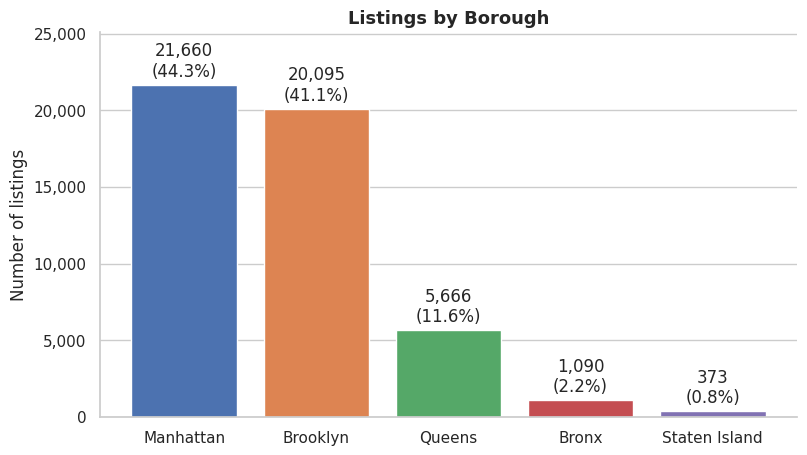

Manhattan + Brooklyn hold 85.4% of all listings; Queens holds 11.6%; Bronx and Staten Island together hold 3.0%.


In [9]:
borough_counts = df["neighbourhood_group"].value_counts().reindex(BOROUGHS)
borough_share = borough_counts / borough_counts.sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(borough_counts.index, borough_counts.values,
              color=[BOROUGH_COLORS[b] for b in borough_counts.index])
ax.bar_label(bars, labels=[f"{n:,}\n({s:.1%})" for n, s in zip(borough_counts, borough_share)], padding=3)
ax.set(title="Listings by Borough", xlabel="", ylabel="Number of listings",
       ylim=(0, borough_counts.max() * 1.16))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
save_fig("01_listings_by_borough")

top2 = borough_share.iloc[:2].sum()
print(f"Manhattan + Brooklyn hold {top2:.1%} of all listings; "
      f"Queens holds {borough_share['Queens']:.1%}; "
      f"Bronx and Staten Island together hold {borough_share[['Bronx', 'Staten Island']].sum():.1%}.")

**Business reading:** the marketplace is essentially a two-borough business. Growth in the outer boroughs is an expansion opportunity, but it starts from a very small base — and, as later charts show, those areas have lower prices, so revenue per new listing will be lower too.

#### Chart 2 — Room type mix
**Why a donut chart:** three parts of a whole. The legend carries the exact counts so the small shared-room slice stays readable.

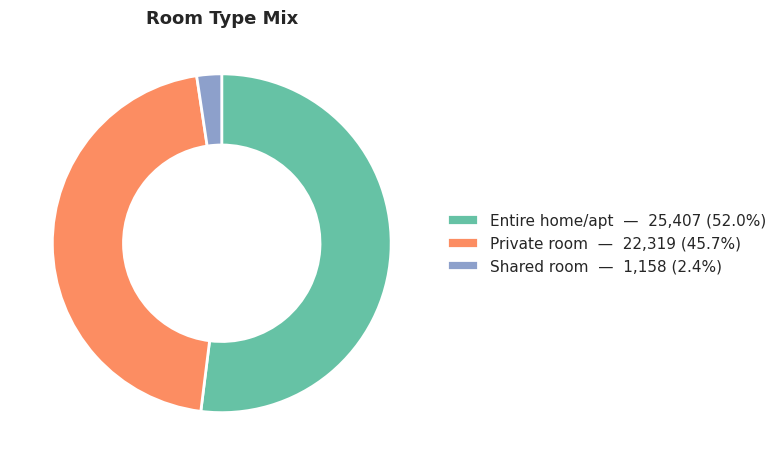

Entire homes: 52.0% | Private rooms: 45.7% | Shared rooms: 2.4%


In [10]:
room_counts = df["room_type"].value_counts().reindex(ROOM_TYPES)
room_share = room_counts / room_counts.sum()

fig, ax = plt.subplots(figsize=(8, 5.5))
wedges, _ = ax.pie(
    room_counts, colors=[ROOM_COLORS[r] for r in ROOM_TYPES], startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
)
ax.legend(wedges, [f"{r}  —  {n:,} ({s:.1%})" for r, n, s in zip(ROOM_TYPES, room_counts, room_share)],
          loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
ax.set_title("Room Type Mix")
save_fig("02_room_type_mix")

print(f"Entire homes: {room_share['Entire home/apt']:.1%} | "
      f"Private rooms: {room_share['Private room']:.1%} | "
      f"Shared rooms: {room_share['Shared room']:.1%}")

**Business reading:** guests are not exclusively choosing whole apartments — private rooms are almost as common. Shared rooms are a niche product; marketing spend aimed at them would reach a very small audience.

#### Chart 3 — Distribution of nightly price
**Why two histograms:** price is heavily right-skewed. The left panel zooms into the range where 99% of listings sit; the right panel shows the full range on a log axis so the luxury tail stays visible.

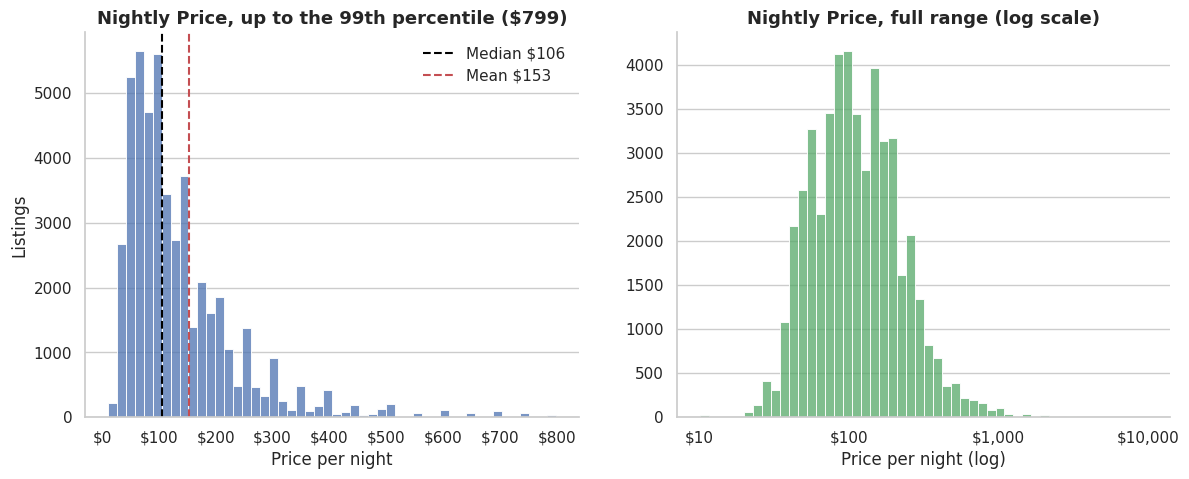

Median $106 | mean $153 | 90th pct $269 | 99th pct $799 | max $10,000
Share of listings under $100: 44.7%


In [11]:
p99 = df["price"].quantile(0.99)
median_price, mean_price = df["price"].median(), df["price"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df.loc[df["price"] <= p99, "price"], bins=50, color="#4C72B0", ax=axes[0])
axes[0].axvline(median_price, color="black", ls="--", lw=1.5, label=f"Median ${median_price:,.0f}")
axes[0].axvline(mean_price, color="#C44E52", ls="--", lw=1.5, label=f"Mean ${mean_price:,.0f}")
axes[0].set(title=f"Nightly Price, up to the 99th percentile (${p99:,.0f})", xlabel="Price per night", ylabel="Listings")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(dollars))
axes[0].legend(frameon=False)

sns.histplot(df["price"], bins=50, log_scale=True, color="#55A868", ax=axes[1])
axes[1].set(title="Nightly Price, full range (log scale)", xlabel="Price per night (log)", ylabel="")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(dollars))

save_fig("03_price_distribution")

print(f"Median ${median_price:,.0f} | mean ${mean_price:,.0f} | 90th pct ${df['price'].quantile(.9):,.0f} | "
      f"99th pct ${p99:,.0f} | max ${df['price'].max():,.0f}")
print(f"Share of listings under $100: {(df['price'] < 100).mean():.1%}")

**Business reading:** the mean overstates what a typical guest pays because a small group of very expensive listings pulls it up. Pricing guidance for hosts should be anchored on medians and percentiles, not averages.

#### Chart 4 — Minimum-stay rules and availability
**Why these two views:** minimum stay is a small set of ordered buckets (bar chart); availability is a continuous 0–365 variable (histogram).

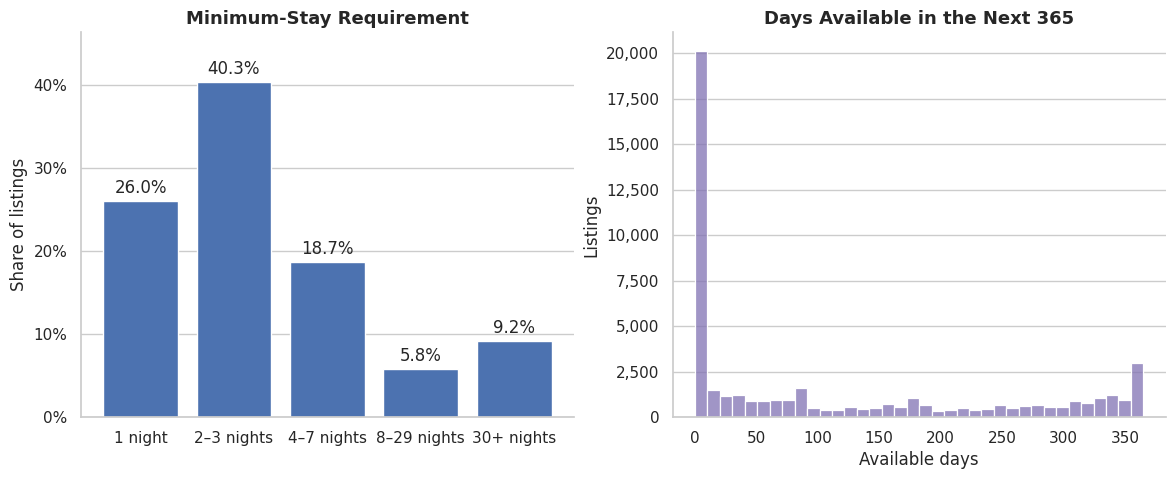

Listings needing 1–3 nights: 66.3% | 30+ night minimum: 9.2%
Listings with zero availability: 35.9% | median availability: 45 days


In [12]:
stay_share = df["min_stay_band"].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(stay_share.index.astype(str), stay_share.values, color="#4C72B0")
axes[0].bar_label(bars, labels=[f"{v:.1%}" for v in stay_share], padding=3)
axes[0].set(title="Minimum-Stay Requirement", xlabel="", ylabel="Share of listings",
            ylim=(0, stay_share.max() * 1.15))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

sns.histplot(df["availability_365"], bins=36, color="#8172B3", ax=axes[1])
axes[1].set(title="Days Available in the Next 365", xlabel="Available days", ylabel="Listings")
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

save_fig("04_stay_rules_and_availability")

print(f"Listings needing 1–3 nights: {stay_share.iloc[:2].sum():.1%} | "
      f"30+ night minimum: {stay_share.iloc[-1]:.1%}")
print(f"Listings with zero availability: {df['no_availability'].mean():.1%} | "
      f"median availability: {df['availability_365'].median():.0f} days")

**Business reading:** most hosts already accept short stays. About a third of listings show no open days at all, which points to either fully booked, blocked, or dormant inventory — worth separating before any occupancy claim is made. The dataset cannot tell those cases apart.

#### Chart 5 — Top 10 neighbourhoods by listing count
**Why a horizontal bar chart:** neighbourhood names are long, and a ranked horizontal layout is the easiest to read. Colour shows which borough each neighbourhood belongs to.

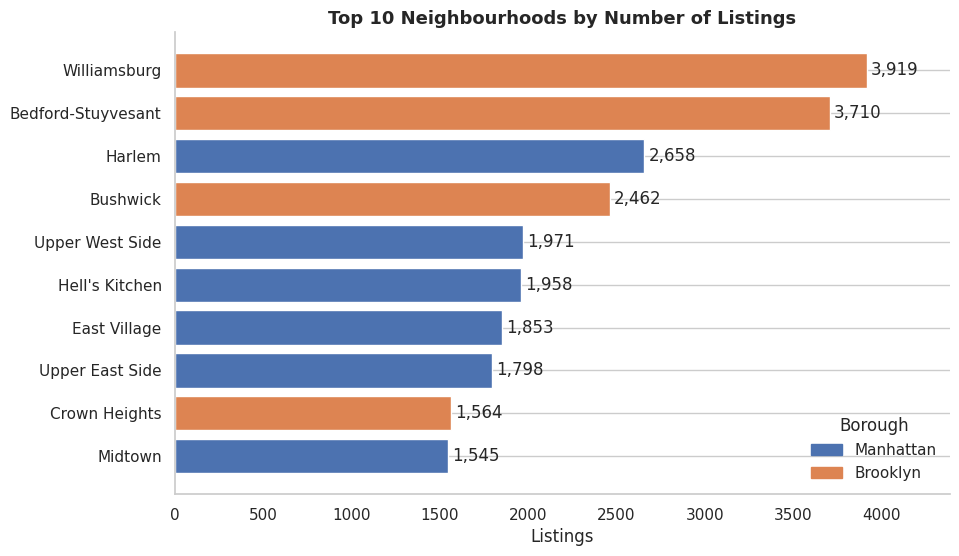

Williamsburg (Brooklyn) leads with 3,919 listings. The top 10 neighbourhoods hold 47.9% of all listings.


In [13]:
top_nbhd = (df.groupby(["neighbourhood", "neighbourhood_group"]).size().rename("listings")
              .reset_index().nlargest(10, "listings").iloc[::-1])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_nbhd["neighbourhood"], top_nbhd["listings"],
               color=[BOROUGH_COLORS[b] for b in top_nbhd["neighbourhood_group"]])
ax.bar_label(bars, labels=[f"{v:,}" for v in top_nbhd["listings"]], padding=3)
ax.set(title="Top 10 Neighbourhoods by Number of Listings", xlabel="Listings", ylabel="")
ax.set_xlim(0, top_nbhd["listings"].max() * 1.12)
handles = [plt.Rectangle((0, 0), 1, 1, color=BOROUGH_COLORS[b]) for b in BOROUGHS
           if b in set(top_nbhd["neighbourhood_group"])]
labels = [b for b in BOROUGHS if b in set(top_nbhd["neighbourhood_group"])]
ax.legend(handles, labels, title="Borough", frameon=False, loc="lower right")
save_fig("05_top_neighbourhoods")

leader = top_nbhd.iloc[-1]
ten_share = top_nbhd["listings"].sum() / len(df)
print(f"{leader['neighbourhood']} ({leader['neighbourhood_group']}) leads with {leader['listings']:,} listings. "
      f"The top 10 neighbourhoods hold {ten_share:.1%} of all listings.")

**Business reading:** the busiest neighbourhoods are a mix of Brooklyn and Manhattan areas, and Brooklyn's supply is concentrated in a few of them (Williamsburg, Bedford-Stuyvesant, Bushwick) rather than spread evenly. Neighbourhood-level, not just borough-level, targeting is warranted for host acquisition and local marketing.

#### Chart 6 — Largest hosts by number of listings
**Why a horizontal bar chart:** a ranked comparison of a small set of named entities. Hosts are identified by `host_id` (a listing title is not a host).

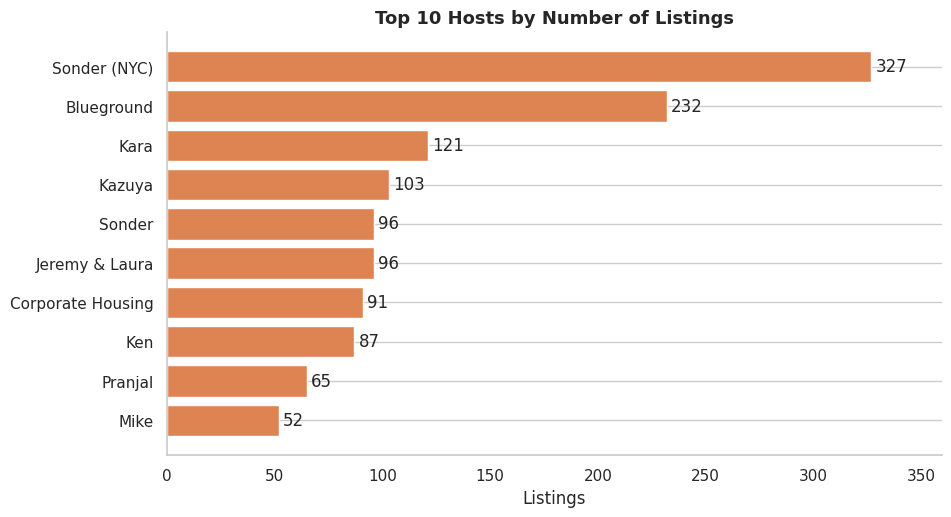

37,455 hosts in total. 343 hosts run 6+ listings and control 9.8% of all listings.


,host_id,host_name,listings,median price ($),boroughs
0,219517861,Sonder (NYC),327,228.0,1
1,107434423,Blueground,232,302.0,2
2,30283594,Kara,121,239.0,1
3,137358866,Kazuya,103,41.0,3
4,12243051,Sonder,96,210.0,1
5,16098958,Jeremy & Laura,96,180.0,1
6,61391963,Corporate Housing,91,142.0,1
7,22541573,Ken,87,210.0,2
8,200380610,Pranjal,65,250.0,1
9,1475015,Mike,52,96.0,1


In [14]:
host_stats = (df.groupby(["host_id", "host_name"])
                .agg(listings=("id", "size"), median_price=("price", "median"),
                     boroughs=("neighbourhood_group", "nunique"))
                .sort_values("listings", ascending=False).reset_index())
top_hosts = host_stats.head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(top_hosts["host_name"][::-1], top_hosts["listings"][::-1], color="#DD8452")
ax.bar_label(bars, padding=3)
ax.set(title="Top 10 Hosts by Number of Listings", xlabel="Listings", ylabel="")
ax.set_xlim(0, top_hosts["listings"].max() * 1.1)
save_fig("06_top_hosts")

multi = host_stats[host_stats["listings"] >= 6]
print(f"{len(host_stats):,} hosts in total. {len(multi):,} hosts run 6+ listings and control "
      f"{multi['listings'].sum() / len(df):.1%} of all listings.")
top_hosts.rename(columns={"median_price": "median price ($)"}).round(0)

**Business reading:** several of the largest accounts are clearly organisations (for example Sonder, Blueground and Corporate Housing), while others carry personal names but still run dozens of listings. Either way these are professional operators — a distinct customer segment that may need bulk tools, account management and different policies, and one that also matters for regulation and reputation.

### 5.2 Bivariate analysis

#### Chart 7 — Price by room type
**Why a box plot:** it compares the whole price distribution (median, spread, skew) across categories, not just the average. Extreme outliers are hidden so the boxes stay readable; the median is labelled.

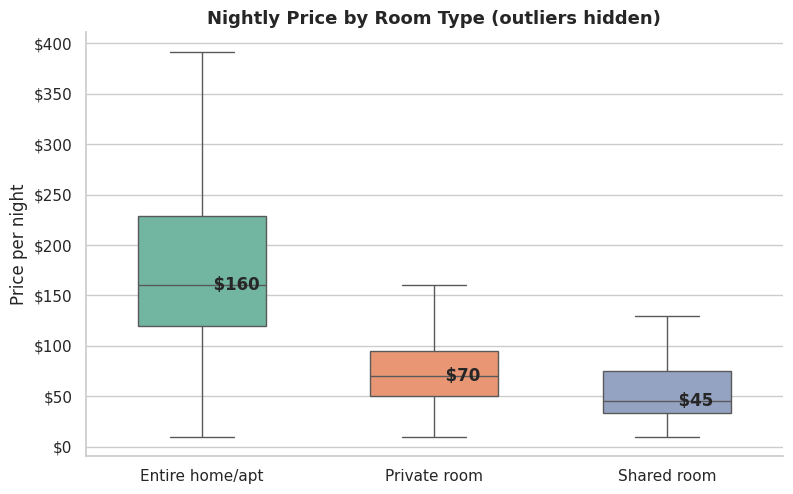

Median price: Entire home/apt $160 | Private room $70 | Shared room $45
An entire home costs 2.3x a private room at the median.


In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x="room_type", y="price", order=ROOM_TYPES, hue="room_type", hue_order=ROOM_TYPES,
            palette=ROOM_COLORS, legend=False, showfliers=False, width=0.55, ax=ax)
medians = df.groupby("room_type")["price"].median().reindex(ROOM_TYPES)
for i, room in enumerate(ROOM_TYPES):
    ax.text(i, medians[room], f"  ${medians[room]:,.0f}", ha="left", va="center", fontweight="bold")
ax.set(title="Nightly Price by Room Type (outliers hidden)", xlabel="", ylabel="Price per night")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(dollars))
save_fig("07_price_by_room_type")

print("Median price: " + " | ".join(f"{r} ${medians[r]:,.0f}" for r in ROOM_TYPES))
print(f"An entire home costs {medians['Entire home/apt'] / medians['Private room']:.1f}x a private room at the median.")

**Business reading:** room type is the first pricing lever. Hosts converting a spare room into a whole-unit listing should expect a very different price tier, and shared rooms sit at the budget floor.

#### Chart 8 — Median price by borough
**Why a sorted bar chart:** one summary number per borough, ranked. Medians are used because of the skew shown in Chart 3.

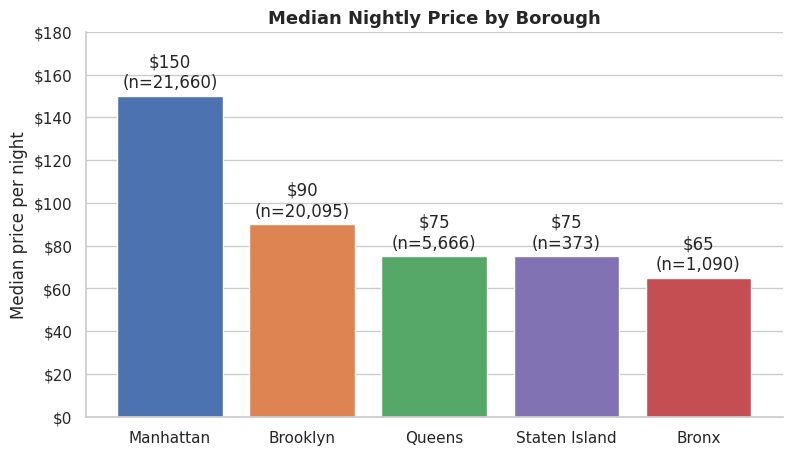

Manhattan's median ($150) is 1.67x Brooklyn's ($90); the Bronx is the cheapest at $65.


In [16]:
borough_price = (df.groupby("neighbourhood_group")["price"].agg(["median", "size"])
                   .reindex(BOROUGHS).sort_values("median", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(borough_price.index, borough_price["median"],
              color=[BOROUGH_COLORS[b] for b in borough_price.index])
ax.bar_label(bars, labels=[f"${m:,.0f}\n(n={n:,})" for m, n in zip(borough_price["median"], borough_price["size"])],
             padding=3)
ax.set(title="Median Nightly Price by Borough", xlabel="", ylabel="Median price per night",
       ylim=(0, borough_price["median"].max() * 1.2))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(dollars))
save_fig("08_median_price_by_borough")

ratio = borough_price.loc["Manhattan", "median"] / borough_price.loc["Brooklyn", "median"]
print(f"Manhattan's median (${borough_price.loc['Manhattan', 'median']:,.0f}) is {ratio:.2f}x Brooklyn's "
      f"(${borough_price.loc['Brooklyn', 'median']:,.0f}); the Bronx is the cheapest "
      f"at ${borough_price.loc['Bronx', 'median']:,.0f}.")

**Business reading:** Manhattan commands a clear premium, and each borough sits in its own price tier. Because Manhattan also mixes in more whole-unit listings, part of this gap is room-type mix — Chart 15 separates the two effects.

#### Chart 9 — Share of listings by price band
**Why an ordered bar chart:** grouping price into ordered bands turns a long-tailed variable into segments that map to real customer budgets. Bands are stored as an ordered categorical, so they appear in price order, not alphabetical order.

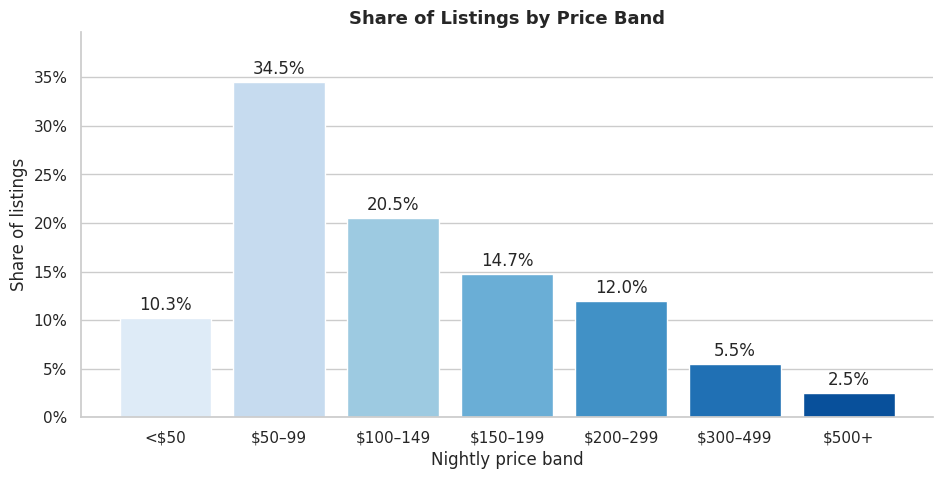

Under $100: 44.7% | under $200: 80.0% | $300 or more: 8.0%


In [17]:
band_share = df["price_band"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(band_share.index.astype(str), band_share.values,
              color=sns.color_palette("Blues", len(band_share)))
ax.bar_label(bars, labels=[f"{v:.1%}" for v in band_share], padding=3)
ax.set(title="Share of Listings by Price Band", xlabel="Nightly price band", ylabel="Share of listings",
       ylim=(0, band_share.max() * 1.15))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
save_fig("09_price_band_share")

cum = band_share.cumsum()
print(f"Under $100: {cum['$50–99']:.1%} | under $200: {cum['$150–199']:.1%} | $300 or more: "
      f"{band_share[['$300–499', '$500+']].sum():.1%}")

**Business reading:** the core market is the $50–$150 range. A budget-based filter for guests (and a "competitive price" indicator for hosts) should be built around these bands, with premium tiers treated as a separate segment.

#### Chart 10 — Guest engagement by price band
**Why paired bars:** two complementary views of the same idea — how actively a listing is reviewed (left), and how often it is never reviewed at all (right).

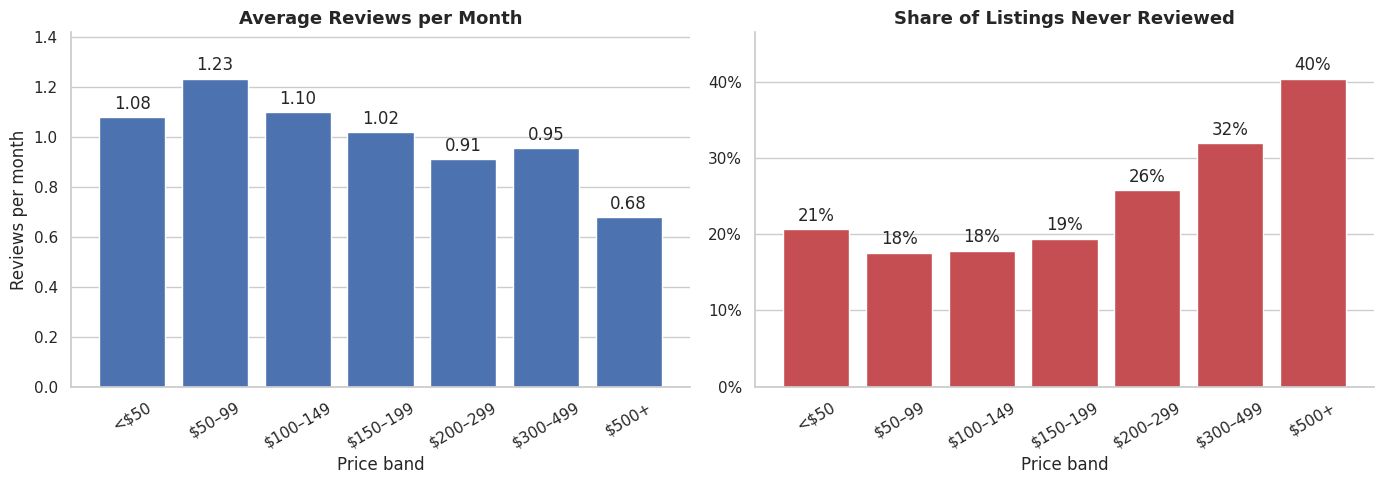

Review rate peaks in the $50–99 band (1.23 per month) and falls to 0.68 in the $500+ band.
Never-reviewed share rises from 18% (lowest band) to 40% at $500+.


In [18]:
band_stats = (df.groupby("price_band", observed=True)
                .agg(listings=("id", "size"),
                     reviews_per_month=("reviews_per_month", "mean"),
                     pct_never_reviewed=("has_reviews", lambda s: 1 - s.mean())))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(band_stats.index.astype(str), band_stats["reviews_per_month"], color="#4C72B0")
axes[0].bar_label(bars, labels=[f"{v:.2f}" for v in band_stats["reviews_per_month"]], padding=3)
axes[0].set(title="Average Reviews per Month", xlabel="Price band", ylabel="Reviews per month",
            ylim=(0, band_stats["reviews_per_month"].max() * 1.15))

bars = axes[1].bar(band_stats.index.astype(str), band_stats["pct_never_reviewed"], color="#C44E52")
axes[1].bar_label(bars, labels=[f"{v:.0%}" for v in band_stats["pct_never_reviewed"]], padding=3)
axes[1].set(title="Share of Listings Never Reviewed", xlabel="Price band", ylabel="",
            ylim=(0, band_stats["pct_never_reviewed"].max() * 1.15))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save_fig("10_engagement_by_price_band")

best = band_stats["reviews_per_month"].idxmax()
print(f"Review rate peaks in the {best} band ({band_stats.loc[best, 'reviews_per_month']:.2f} per month) "
      f"and falls to {band_stats['reviews_per_month'].iloc[-1]:.2f} in the $500+ band.")
print(f"Never-reviewed share rises from {band_stats['pct_never_reviewed'].min():.0%} (lowest band) "
      f"to {band_stats.loc['$500+', 'pct_never_reviewed']:.0%} at $500+.")

**Business reading:** guest activity stays at roughly 1.0–1.2 reviews a month through the $200 mark and drops off mainly at the top end. Premium listings carry more risk of sitting idle, so hosts in the upper bands benefit most from pricing support and stronger listing quality. Reviews are a proxy for activity, not bookings, and higher-priced stays may simply generate fewer or slower reviews.

#### Chart 11 — Engagement by minimum-stay requirement
**Why a bar chart with sample sizes:** minimum stay is an ordered category; showing *n* for each bar makes clear that every bucket is based on a substantial number of listings.

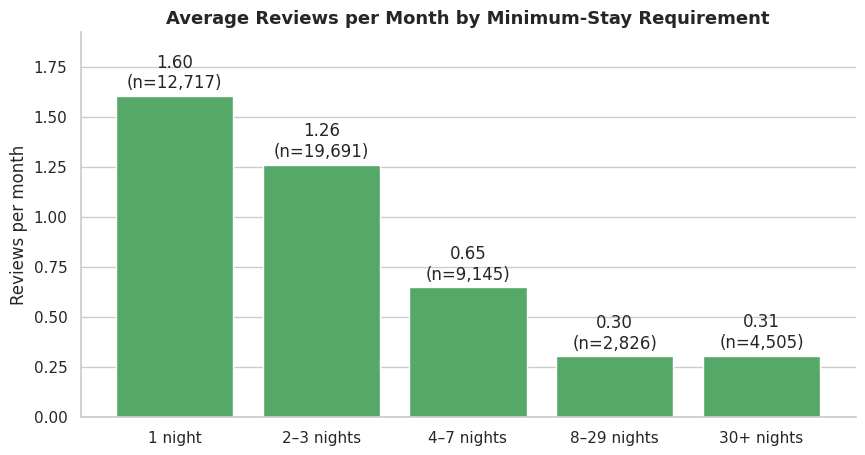

1-night listings average 1.60 reviews/month vs 0.30 for listings requiring 8+ nights (5.3x).


In [19]:
stay_stats = (df.groupby("min_stay_band", observed=True)
                .agg(listings=("id", "size"), reviews_per_month=("reviews_per_month", "mean")))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stay_stats.index.astype(str), stay_stats["reviews_per_month"], color="#55A868")
ax.bar_label(bars, labels=[f"{r:.2f}\n(n={n:,})" for r, n in zip(stay_stats["reviews_per_month"], stay_stats["listings"])],
             padding=3)
ax.set(title="Average Reviews per Month by Minimum-Stay Requirement", xlabel="", ylabel="Reviews per month",
       ylim=(0, stay_stats["reviews_per_month"].max() * 1.2))
save_fig("11_engagement_by_min_stay")

short, long_ = stay_stats["reviews_per_month"].iloc[0], stay_stats["reviews_per_month"].iloc[-2:].mean()
print(f"1-night listings average {short:.2f} reviews/month vs {long_:.2f} for listings requiring 8+ nights "
      f"({short / long_:.1f}x).")

**Business reading:** short-stay listings are reviewed far more often, and the minimum stay is a setting hosts control, so it is the clearest host-side lever in the data. Two caveats: long stays naturally mean fewer, longer bookings and therefore fewer reviews, so part of the gap is mechanical; and some long minimums may reflect New York's short-term-rental rules rather than host choice. The chart shows an association, not proof that shortening a minimum stay would raise reviews — that would need a controlled test.

#### Chart 12 — Neighbourhoods: volume versus price
**Why a scatter plot:** each point is a neighbourhood with 50+ listings. Position shows how big it is (x, log scale) and how expensive it is (y); colour shows the borough. This surfaces neighbourhoods that are both large and high-priced.

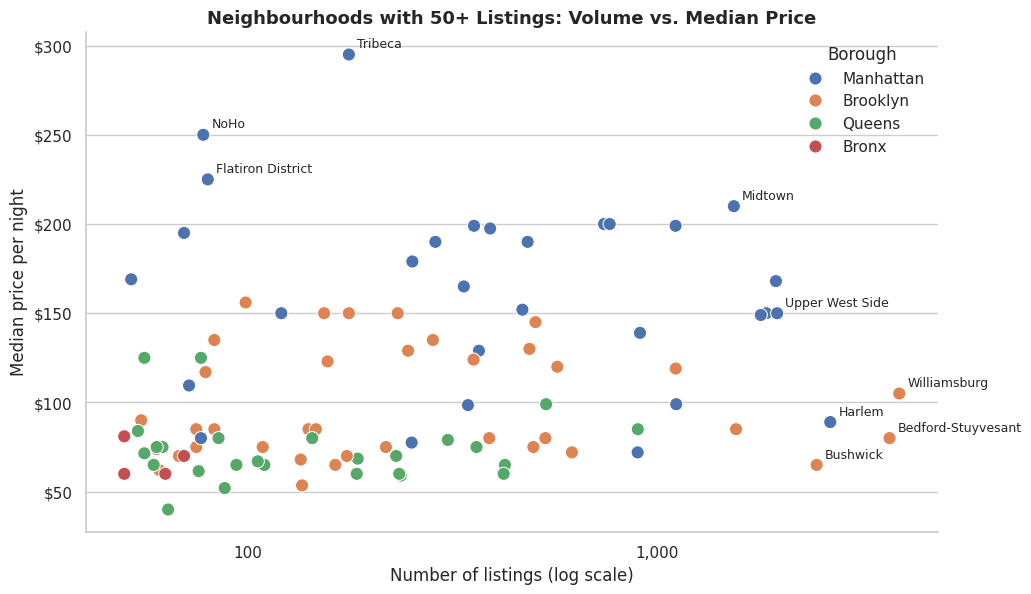

98 neighbourhoods have 50+ listings. Highest median price: Tribeca ($295); lowest: Corona ($40).


In [20]:
nbhd = (df.groupby(["neighbourhood", "neighbourhood_group"])
          .agg(listings=("id", "size"), median_price=("price", "median")).reset_index())
nbhd = nbhd[nbhd["listings"] >= 50]

fig, ax = plt.subplots(figsize=(11, 6.5))
present = [b for b in BOROUGHS if b in set(nbhd["neighbourhood_group"])]
sns.scatterplot(data=nbhd, x="listings", y="median_price", hue="neighbourhood_group", hue_order=present,
                palette=BOROUGH_COLORS, s=90, edgecolor="white", ax=ax)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(dollars))
ax.set(title="Neighbourhoods with 50+ Listings: Volume vs. Median Price",
       xlabel="Number of listings (log scale)", ylabel="Median price per night")

to_label = pd.concat([nbhd.nlargest(5, "listings"), nbhd.nlargest(4, "median_price")]).drop_duplicates("neighbourhood")
for _, r in to_label.iterrows():
    ax.annotate(r["neighbourhood"], (r["listings"], r["median_price"]),
                xytext=(6, 5), textcoords="offset points", fontsize=9)
ax.legend(title="Borough", frameon=False)
save_fig("12_neighbourhood_volume_vs_price")

print(f"{len(nbhd)} neighbourhoods have 50+ listings. "
      f"Highest median price: {nbhd.loc[nbhd['median_price'].idxmax(), 'neighbourhood']} "
      f"(${nbhd['median_price'].max():,.0f}); lowest: {nbhd.loc[nbhd['median_price'].idxmin(), 'neighbourhood']} "
      f"(${nbhd['median_price'].min():,.0f}).")

**Business reading:** Manhattan neighbourhoods occupy the upper half of the chart at every size, from small premium areas (Tribeca, NoHo, Flatiron) to large ones such as Midtown. Brooklyn's biggest neighbourhoods — Williamsburg, Bedford-Stuyvesant and Bushwick — are the largest in the city by listings but sit at much lower price points, and Queens and the Bronx cluster at the bottom. Host-acquisition and pricing strategy therefore differs by neighbourhood: volume plays in the large Brooklyn areas, margin plays in the premium Manhattan ones.

#### Chart 13 — Geographic distribution
**Why a coordinate scatter:** latitude and longitude turn the listings into a map-like view without needing a map tile service. The left panel colours by borough; the right by nightly price (log-scaled colour, so that the bulk of listings remain distinguishable).

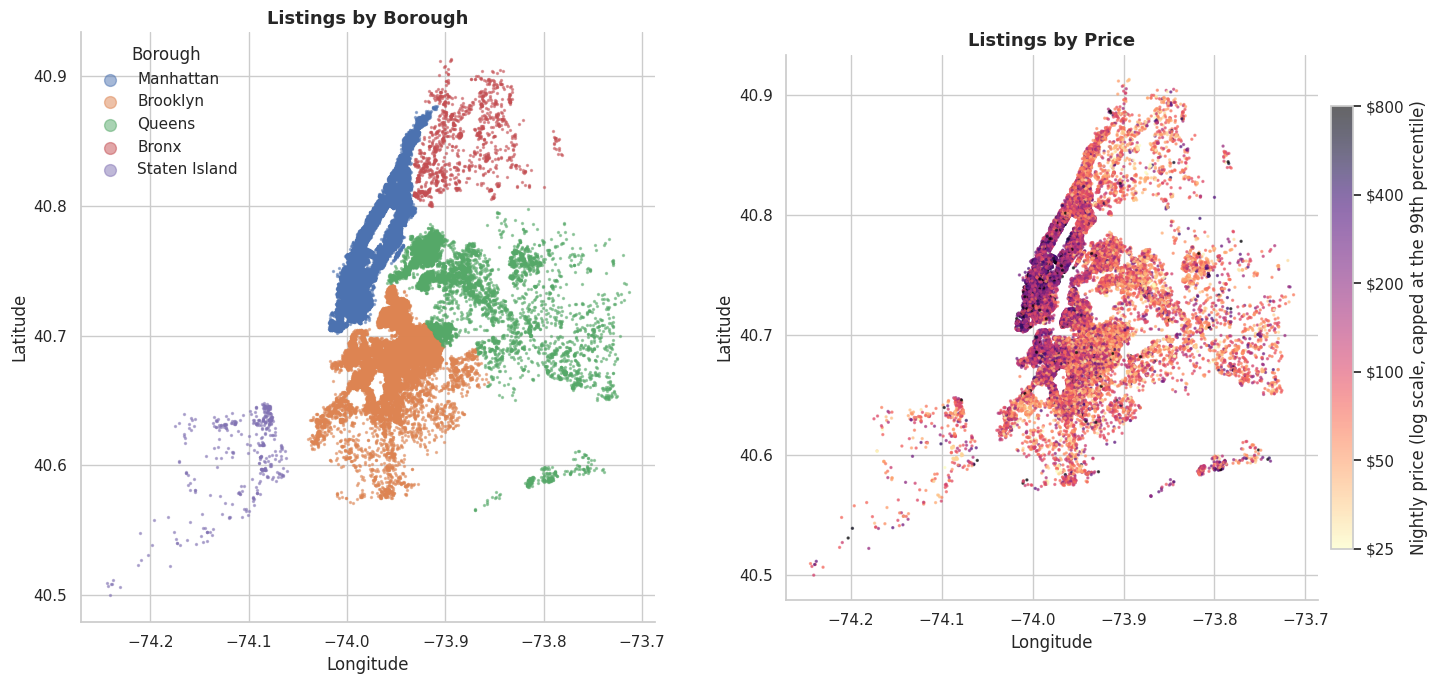

In [21]:
from matplotlib.colors import LogNorm

aspect = 1 / np.cos(np.deg2rad(df["latitude"].mean()))   # keep distances roughly true to scale
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for borough in BOROUGHS:
    sub = df[df["neighbourhood_group"] == borough]
    axes[0].scatter(sub["longitude"], sub["latitude"], s=2, alpha=0.5, color=BOROUGH_COLORS[borough], label=borough)
axes[0].legend(markerscale=6, frameon=False, title="Borough")
axes[0].set_title("Listings by Borough")

shuffled = df.sample(frac=1, random_state=RANDOM_STATE)   # random draw order avoids bias from overplotting
sc = axes[1].scatter(shuffled["longitude"], shuffled["latitude"], c=shuffled["price"].clip(upper=p99),
                     s=2, alpha=0.6, cmap="magma_r", norm=LogNorm(vmin=25, vmax=p99))
cbar = fig.colorbar(sc, ax=axes[1], shrink=0.75, pad=0.02)
cbar.set_ticks([25, 50, 100, 200, 400, 800])
cbar.set_ticklabels(["$25", "$50", "$100", "$200", "$400", "$800"])
cbar.ax.minorticks_off()
cbar.set_label("Nightly price (log scale, capped at the 99th percentile)")
axes[1].set_title("Listings by Price")

for ax in axes:
    ax.set_aspect(aspect)
    ax.grid(True)
    ax.set(xlabel="Longitude", ylabel="Latitude")
plt.tight_layout()
save_fig("13_geographic_distribution")

**Business reading:** the price map shows the highest prices concentrated in Manhattan, especially below Central Park, with the darker points thinning out toward the outer boroughs; the part of Brooklyn nearest Manhattan is also visibly pricier than the rest of the borough. Location clearly matters for price, which supports building location-aware price recommendations at neighbourhood level.

#### Chart 14 — Host mix by borough
**Why a 100% stacked bar:** the question is composition — what share of each borough's listings belong to single-property versus multi-listing hosts — so every bar is normalised to the same length.

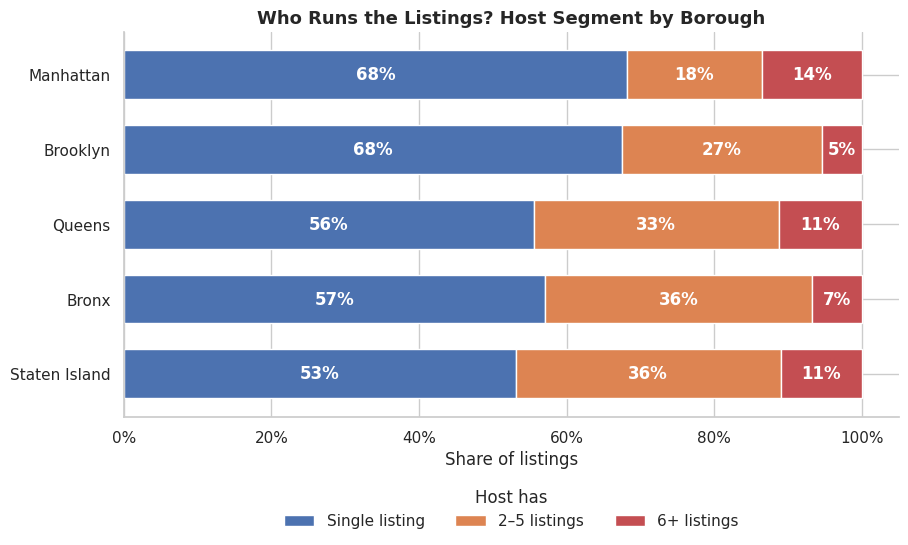

Listings owned by hosts with 6+ listings: Manhattan 13.6% vs Brooklyn 5.5%.


,listings,median_price,median_availability,reviews_per_month
host_segment,,,,
Single listing,32301,119.0,6.0,0.95
2–5 listings,11792,85.0,116.0,1.56
6+ listings,4791,129.0,310.0,0.87


In [22]:
segment_mix = (pd.crosstab(df["neighbourhood_group"], df["host_segment"], normalize="index")
                 .reindex(BOROUGHS))

fig, ax = plt.subplots(figsize=(10, 5))
segment_mix.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#C44E52"], width=0.65)
ax.invert_yaxis()
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.0%}" if v > 0.04 else "" for v in container.datavalues],
                 label_type="center", color="white", fontweight="bold")
ax.set(title="Who Runs the Listings? Host Segment by Borough", xlabel="Share of listings", ylabel="")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.legend(title="Host has", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
save_fig("14_host_segment_by_borough")

seg_profile = (df.groupby("host_segment", observed=True)
                 .agg(listings=("id", "size"), median_price=("price", "median"),
                      median_availability=("availability_365", "median"),
                      reviews_per_month=("reviews_per_month", "mean")).round(2))
print(f"Listings owned by hosts with 6+ listings: Manhattan {segment_mix.loc['Manhattan', '6+ listings']:.1%} "
      f"vs Brooklyn {segment_mix.loc['Brooklyn', '6+ listings']:.1%}.")
seg_profile

**Business reading:** Manhattan has the highest share of professional-operator listings and, because it is so large, most of them in absolute terms. Listings from hosts with 6+ properties stay open for far more days than those of single-property hosts (see the table above) — consistent with commercial inventory that is always for sale, though the data cannot separate that from under-booked stock. The two groups behave differently enough that they should not be analysed or supported as one population.

### 5.3 Multivariate analysis

#### Chart 15 — Median price by borough and room type
**Why a heatmap:** two categorical dimensions and one numeric value; a heatmap shows the full grid at once. Cells based on fewer than 30 listings are masked because their medians are not reliable.

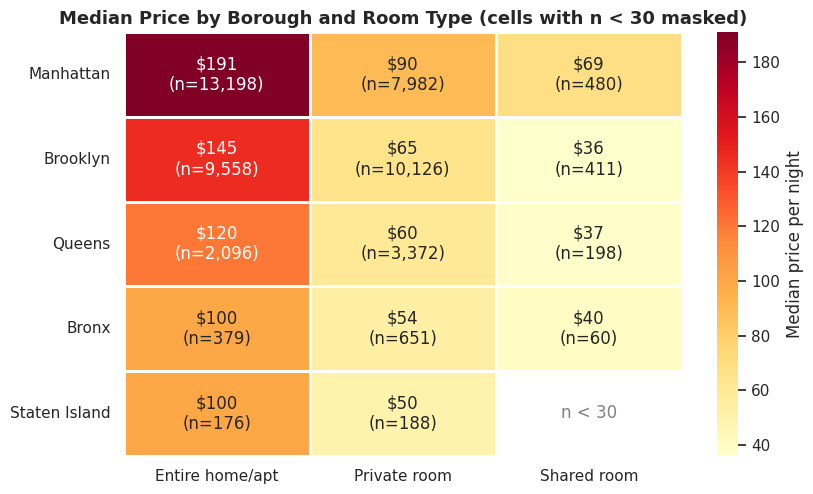

Entire homes: Manhattan $191 vs Brooklyn $145 (1.32x). Private rooms: Manhattan $90 vs Brooklyn $65 (1.38x).


In [23]:
MIN_CELL = 30
pivot_med = df.pivot_table(index="neighbourhood_group", columns="room_type", values="price",
                           aggfunc="median").reindex(index=BOROUGHS, columns=ROOM_TYPES)
pivot_n = df.pivot_table(index="neighbourhood_group", columns="room_type", values="price",
                         aggfunc="size").reindex(index=BOROUGHS, columns=ROOM_TYPES)
shown = pivot_med.where(pivot_n >= MIN_CELL)
labels = np.array([["n/a" if pd.isna(v) else f"${v:,.0f}\n(n={int(n):,})"
                    for v, n in zip(row_v, row_n)] for row_v, row_n in zip(shown.values, pivot_n.values)])

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(shown, annot=labels, fmt="", cmap="YlOrRd", cbar_kws={"label": "Median price per night"},
            linewidths=2, linecolor="white", ax=ax)
ax.set(title=f"Median Price by Borough and Room Type (cells with n < {MIN_CELL} masked)", xlabel="", ylabel="")
ax.tick_params(axis="y", rotation=0)
ax.grid(False)
for i, j in zip(*np.where(shown.isna().to_numpy())):
    ax.text(j + 0.5, i + 0.5, f"n < {MIN_CELL}", ha="center", va="center", color="grey")
save_fig("15_price_heatmap_borough_room")

m_ent, b_ent = pivot_med.loc["Manhattan", "Entire home/apt"], pivot_med.loc["Brooklyn", "Entire home/apt"]
m_prv, b_prv = pivot_med.loc["Manhattan", "Private room"], pivot_med.loc["Brooklyn", "Private room"]
print(f"Entire homes: Manhattan ${m_ent:,.0f} vs Brooklyn ${b_ent:,.0f} ({m_ent / b_ent:.2f}x). "
      f"Private rooms: Manhattan ${m_prv:,.0f} vs Brooklyn ${b_prv:,.0f} ({m_prv / b_prv:.2f}x).")

**Business reading:** the Manhattan premium holds *within* each room type, so it is not just a mix effect. Room type and location each contribute, and a fair price benchmark for a host needs both — a single citywide average would mislead in either direction.

#### Chart 16 — Correlation between numeric variables
**Why a Spearman heatmap:** the variables are heavily skewed with outliers, so rank-based (Spearman) correlation is more trustworthy than Pearson. Only the lower triangle is shown to avoid repetition.

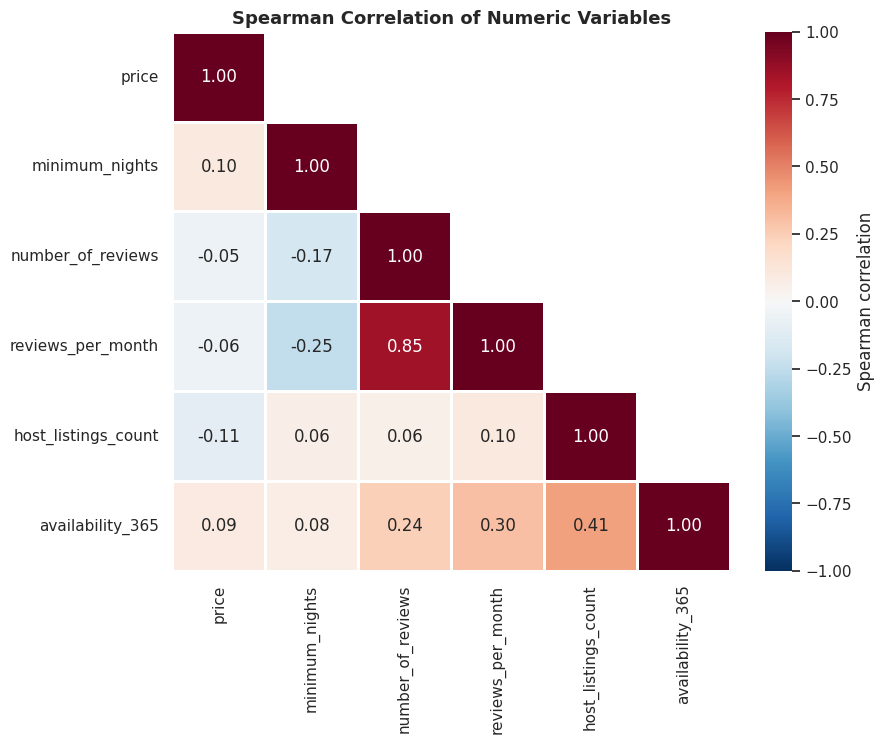

Strongest relationships:
            var_1               var_2   rho
reviews_per_month   number_of_reviews  0.85
 availability_365 host_listings_count  0.41
 availability_365   reviews_per_month  0.30
reviews_per_month      minimum_nights -0.25


In [24]:
num_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
            "host_listings_count", "availability_365"]
corr = df[num_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            linewidths=1, linecolor="white", cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set_title("Spearman Correlation of Numeric Variables")
ax.grid(False)
save_fig("16_correlation_heatmap")

pairs = (corr.where(~mask & (corr < 1)).stack().rename("rho").reset_index()
             .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
pairs = pairs.loc[pairs["rho"].abs().sort_values(ascending=False).index].head(4)
print("Strongest relationships:")
print(pairs.round(2).to_string(index=False))

**Business reading:** the strongest links are between the two review measures (expected, since they are computed from the same reviews) and between how many listings a host has and how many days those listings stay open. Price has only weak relationships with everything else (rank correlations of about 0.1 or less), so price cannot be explained by these operational variables alone — location and room type (Chart 15) carry most of the signal. Any later price model should start from those categorical features.

#### Chart 17 — Pair plot of key variables
**Why a pair plot:** one figure that shows every pairwise relationship and each variable's distribution, split by room type. A random sample of 3,000 listings keeps it fast, and price/stay/reviews are log-transformed because of their skew.

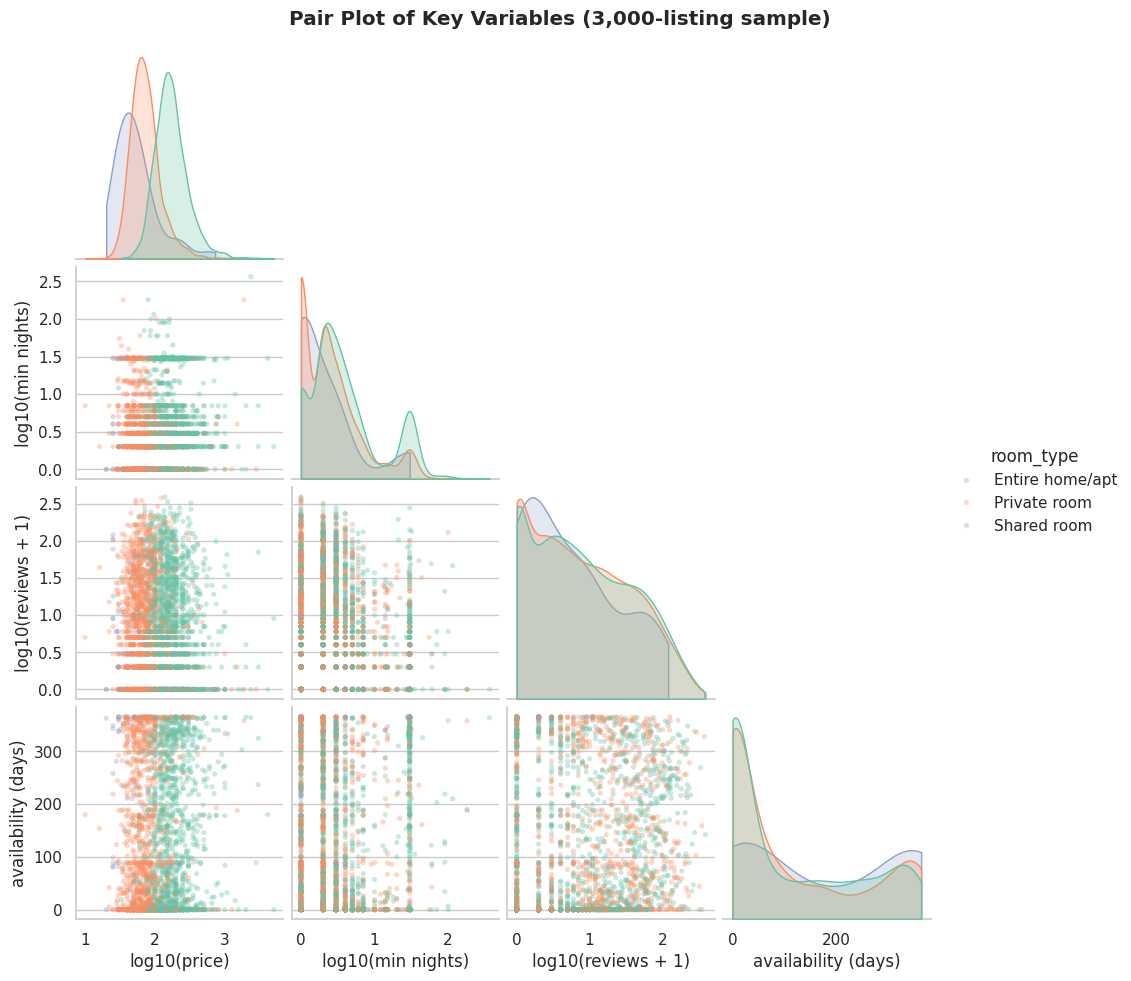

In [25]:
sample = df.sample(3000, random_state=RANDOM_STATE)
plot_df = pd.DataFrame({
    "log10(price)": np.log10(sample["price"]),
    "log10(min nights)": np.log10(sample["minimum_nights"]),
    "log10(reviews + 1)": np.log10(sample["number_of_reviews"] + 1),
    "availability (days)": sample["availability_365"],
    "room_type": sample["room_type"],
})
g = sns.pairplot(plot_df, hue="room_type", hue_order=ROOM_TYPES, palette=ROOM_COLORS, corner=True,
                 diag_kind="kde", diag_kws=dict(common_norm=False, cut=0),
                 plot_kws=dict(alpha=0.35, s=14, edgecolor="none"), height=2.4)
g.figure.suptitle("Pair Plot of Key Variables (3,000-listing sample)", y=1.02, fontweight="bold")
save_fig("17_pair_plot")

**Business reading:** entire homes sit clearly higher on log-price than private and shared rooms (which overlap), confirming room type as a primary segmentation variable. The minimum-night panels show a distinct cluster at 30 nights, and the other pairs show little strong linear structure. Diffuse relationships like these suggest that any later price model should lean on categorical features and non-linear methods rather than a simple linear fit.

## 6. Statistical testing

Charts suggest price differs by location. Two non-parametric tests check whether those differences are larger than chance — non-parametric because price is far from normally distributed.

With roughly 49,000 rows almost any difference is "statistically significant", so the **effect sizes** matter more than the p-values.

In [26]:
# 1) Do nightly prices differ across the five boroughs? (Kruskal-Wallis H test)
price_groups = [g["price"].to_numpy() for _, g in df.groupby("neighbourhood_group")]
h_stat, p_kw = stats.kruskal(*price_groups)
n = len(df)
epsilon_sq = h_stat * (n + 1) / (n**2 - 1)      # effect size for Kruskal-Wallis

print("Kruskal-Wallis: price across boroughs")
print(f"  H = {h_stat:,.1f}, p = {fmt_p(p_kw)}, epsilon-squared = {epsilon_sq:.3f}")

# 2) Within entire homes, is Manhattan pricier than Brooklyn? (Mann-Whitney U test)
manhattan = df.loc[(df["neighbourhood_group"] == "Manhattan") & (df["room_type"] == "Entire home/apt"), "price"]
brooklyn = df.loc[(df["neighbourhood_group"] == "Brooklyn") & (df["room_type"] == "Entire home/apt"), "price"]
u_stat, p_mw = stats.mannwhitneyu(manhattan, brooklyn, alternative="two-sided")
cles = u_stat / (len(manhattan) * len(brooklyn))  # probability a random Manhattan listing is pricier

print("\nMann-Whitney U: Manhattan vs Brooklyn, entire homes only")
print(f"  U = {u_stat:,.0f}, p = {fmt_p(p_mw)}")
print(f"  Probability a random Manhattan entire home is priced above a random Brooklyn one: {cles:.1%}")
print(f"  Median difference: ${manhattan.median() - brooklyn.median():,.0f} per night")

Kruskal-Wallis: price across boroughs
  H = 7,023.1, p = < 1e-300, epsilon-squared = 0.144

Mann-Whitney U: Manhattan vs Brooklyn, entire homes only
  U = 84,353,952, p = < 1e-300
  Probability a random Manhattan entire home is priced above a random Brooklyn one: 66.9%
  Median difference: $46 per night


**Reading the results.** Both tests reject "no difference" decisively. The Kruskal-Wallis effect size means borough alone accounts for roughly 14% of the variation in price ranks — a large effect for a single categorical variable — and the Mann-Whitney result means a random Manhattan entire home is priced above a random Brooklyn one roughly two times out of three. These are associations in one 2019 snapshot; they do not, on their own, prove that location *causes* the price difference (amenities, size and quality are not in the data).

## 7. Findings, recommendations and limitations

### What the data says

| Question | Finding |
|---|---|
| **Supply** | Manhattan and Brooklyn hold about 85% of listings. The busiest individual neighbourhoods are Williamsburg and Bedford-Stuyvesant in Brooklyn, followed by Harlem and Bushwick. |
| **Room types** | Entire homes and private rooms are close to an even split; shared rooms are marginal. |
| **Pricing** | Typical price is ~$106 (median). Both borough and room type shift the price tier significantly, and the Manhattan premium persists inside every room type. |
| **Engagement** | Reviews per month stay roughly level through the mainstream price bands and decline above ~$200; short minimum stays (1–3 nights) coincide with much higher review rates than 8+ night minimums. |
| **Hosts** | Professional operators (6+ listings) are a small share of hosts but a visible share of listings, concentrated in Manhattan, and keep inventory open much longer. |

### Recommendations

1. **Build price guidance around location *and* room type.** Show hosts a benchmark for their neighbourhood and room type, expressed as a median and a range, not a citywide average.
2. **Test shorter minimum stays.** Invite hosts with 8+ night minimums to trial 1–3 nights, ideally as a controlled experiment; it is the largest host-controllable difference in the data, but the data alone cannot show it is causal.
3. **Give premium listings extra support.** Listings above $300 are much more likely to sit unreviewed; targeted pricing and listing-quality nudges would help this segment most.
4. **Treat professional operators as their own segment.** Different tooling, policies and success metrics from single-property hosts.
5. **Target growth by neighbourhood, not just borough.** Large mid-priced Brooklyn neighbourhoods and small premium Manhattan ones call for different acquisition strategies; outer-borough expansion should expect lower revenue per listing.
6. **Improve the data.** Adding booking records, ratings, amenities, property size and guest attributes would allow real demand and satisfaction analysis, which this dataset cannot support.

### Limitations

- **Reviews are not bookings.** All engagement findings rely on review counts as a proxy for guest activity.
- **Availability is ambiguous.** `availability_365 = 0` can mean fully booked, blocked by the host, or inactive.
- **Listed prices are not realised prices.** The dataset holds asking prices, not what guests actually paid.
- **One snapshot, one year.** No seasonality, trends or cause-and-effect can be established.
- **No guest-side data.** Satisfaction, guest origin and trip purpose cannot be measured.

### Possible next steps
Price-prediction baseline (regularised linear model versus gradient boosting with cross-validation), text analysis of listing titles, spatial clustering of neighbourhood price zones, and an interactive dashboard for stakeholders.